In [23]:
import os
import numpy as np
import matplotlib.pyplot as plt

# ------------------------------
# 1) load MRI data
# ------------------------------
data_candidates = "LAB2/lab2_MRI.npy"

img = None
img = np.load(data_candidates)

img = img.astype(np.float64)
if img.ndim == 3:
    img = img.mean(axis=-1)

H, W = img.shape
print("Image shape:", img.shape, "dtype:", img.dtype)

plt.figure(figsize=(5, 5))
plt.imshow(img, cmap="gray")
plt.title("Original MRI")
plt.axis("off")
plt.show()

FileNotFoundError: [Errno 2] No such file or directory: 'LAB2/lab2_MRI.npy'

In [24]:
for p in [
    "lab2_MRI.npy",
    "LAB2/lab2_MRI.npy",
    r"D:/coding/DIP_project/LAB2/lab2_MRI.npy"
]:
    print(p, "=>", os.path.exists(p))

lab2_MRI.npy => True
LAB2/lab2_MRI.npy => False
D:/coding/DIP_project/LAB2/lab2_MRI.npy => True


In [25]:
img_raw = np.load("lab2_MRI.npy")
print("shape:", img_raw.shape)
print("ndim :", img_raw.ndim)
print("dtype:", img_raw.dtype, "min/max:", img_raw.min(), img_raw.max())

shape: (512, 512)
ndim : 2
dtype: float64 min/max: 0.0 726.0


shape=(512, 512), ndim=2, dtype=float64


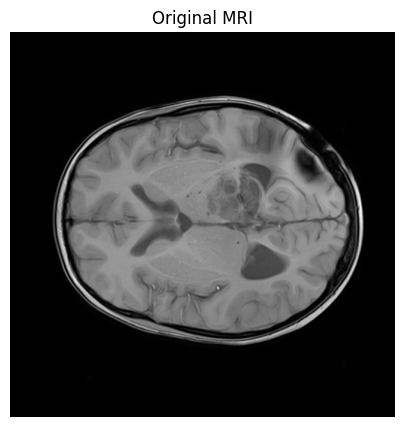

In [26]:
import numpy as np
import matplotlib.pyplot as plt

img = np.load("lab2_MRI.npy").astype(np.float64)

if img.ndim == 3:
    img = img.mean(axis=-1)  

H, W = img.shape
print(f"shape={img.shape}, ndim={img.ndim}, dtype={img.dtype}")

plt.figure(figsize=(5, 5))
plt.imshow(img, cmap="gray")
plt.title("Original MRI")
plt.axis("off")
plt.show()

In [29]:
def get_rotation_matrix(theta, cx, cy):
    c, s = np.cos(theta), np.sin(theta)
    T1 = np.array([[1, 0, -cx], [0, 1, -cy], [0, 0, 1]], dtype=np.float64)
    R = np.array([[c, -s, 0], [s, c, 0], [0, 0, 1]], dtype=np.float64)
    T2 = np.array([[1, 0, cx], [0, 1, cy], [0, 0, 1]], dtype=np.float64)
    return T2 @ R @ T1


def sample_nearest(im, x, y):
    h, w = im.shape
    xi, yi = int(np.rint(x)), int(np.rint(y))
    if xi < 0 or xi >= w or yi < 0 or yi >= h:
        return 0.0
    return im[yi, xi]


def sample_bilinear(im, x, y):
    h, w = im.shape
    x0, y0 = int(np.floor(x)), int(np.floor(y))
    x1, y1 = x0 + 1, y0 + 1
    if x0 < 0 or y0 < 0 or x1 >= w or y1 >= h:
        return 0.0
    dx, dy = x - x0, y - y0
    v00, v10 = im[y0, x0], im[y0, x1]
    v01, v11 = im[y1, x0], im[y1, x1]
    return (1 - dx) * (1 - dy) * v00 + dx * (1 - dy) * v10 + (1 - dx) * dy * v01 + dx * dy * v11


def warp_affine_inverse(im, M, mode="nearest"):
    h, w = im.shape
    out = np.zeros((h, w), dtype=np.float64)
    Minv = np.linalg.inv(M)
    for v in range(h):
        for u in range(w):
            x, y, _ = Minv @ np.array([u, v, 1.0], dtype=np.float64)
            if mode == "nearest":
                out[v, u] = sample_nearest(im, x, y)
            elif mode == "bilinear":
                out[v, u] = sample_bilinear(im, x, y)
            else:
                raise ValueError("mode must be 'nearest' or 'bilinear'")
    return out


theta = np.pi / 5
cx, cy = (W - 1) / 2.0, (H - 1) / 2.0
M_pos = get_rotation_matrix(theta, cx, cy)
M_neg = get_rotation_matrix(-theta, cx, cy)

rot_nn = warp_affine_inverse(img, M_pos, mode="nearest")
rec_nn = warp_affine_inverse(rot_nn, M_neg, mode="nearest")
rot_bl = warp_affine_inverse(img, M_pos, mode="bilinear")
rec_bl = warp_affine_inverse(rot_bl, M_neg, mode="bilinear")

diff_nn = np.abs(img - rec_nn)
diff_bl = np.abs(img - rec_bl)

def metrics(err):
    mae = np.mean(np.abs(err))
    mse = np.mean(err ** 2)
    rmse = np.sqrt(mse)
    return mae, mse, rmse

print("Nearest :", metrics(img - rec_nn))
print("Bilinear:", metrics(img - rec_bl))

Nearest : (np.float64(1.3336334228515625), np.float64(102.79024505615234), np.float64(10.138552414233125))
Bilinear: (np.float64(2.093147893655308), np.float64(38.98788305559141), np.float64(6.244027791064948))


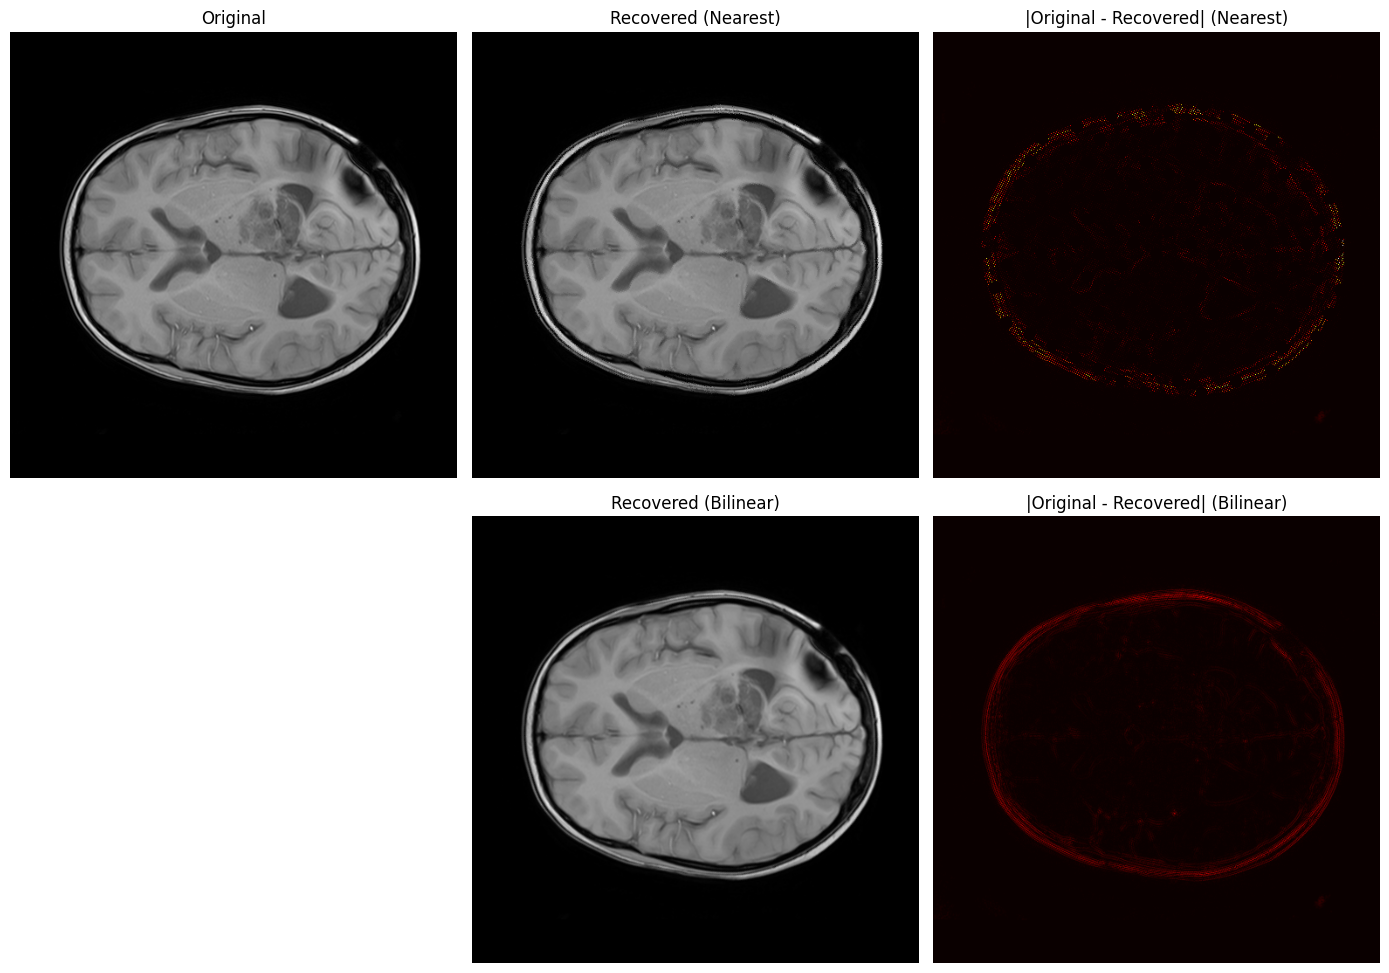

In [32]:
# 依赖前面已计算：img, rec_nn, rec_bl, diff_nn, diff_bl

vmax = max(np.max(diff_nn), np.max(diff_bl), 1e-8)

plt.figure(figsize=(14, 10))

# 第一行：原图 + 最近邻恢复 + 最近邻误差
plt.subplot(2, 3, 1)
plt.imshow(img, cmap="gray")
plt.title("Original")
plt.axis("off")

plt.subplot(2, 3, 2)
plt.imshow(rec_nn, cmap="gray")
plt.title("Recovered (Nearest)")
plt.axis("off")

plt.subplot(2, 3, 3)
plt.imshow(diff_nn, cmap="hot", vmin=0, vmax=vmax)
plt.title("|Original - Recovered| (Nearest)")
plt.axis("off")

# 第二行：双线性恢复 + 双线性误差（左下角留空，保持布局一致）
plt.subplot(2, 3, 5)
plt.imshow(rec_bl, cmap="gray")
plt.title("Recovered (Bilinear)")
plt.axis("off")

plt.subplot(2, 3, 6)
plt.imshow(diff_bl, cmap="hot", vmin=0, vmax=vmax)
plt.title("|Original - Recovered| (Bilinear)")
plt.axis("off")

plt.tight_layout()
plt.show()

In [30]:
from matplotlib.patches import Rectangle
# 两种方法“恢复误差差异”图：越大表示两种插值差异越明显
delta = np.abs(diff_nn - diff_bl)

# 找差异最大的点（避免边缘，防止放大框越界）
margin = 40
core = delta[margin:-margin, margin:-margin]
peak_idx = np.unravel_index(np.argmax(core), core.shape)
cy_peak, cx_peak = peak_idx[0] + margin, peak_idx[1] + margin

# 放大框大小
box = 80
x0 = max(cx_peak - box // 2, 0)
y0 = max(cy_peak - box // 2, 0)
x1 = min(x0 + box, img.shape[1])
y1 = min(y0 + box, img.shape[0])

# 为了保证框是 box*box，必要时回调起点
x0 = max(x1 - box, 0)
y0 = max(y1 - box, 0)

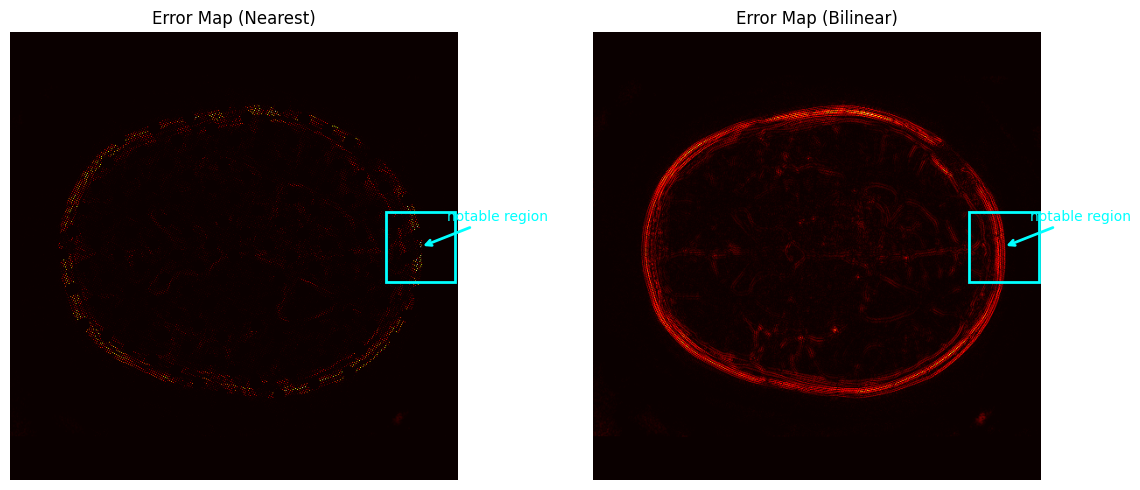

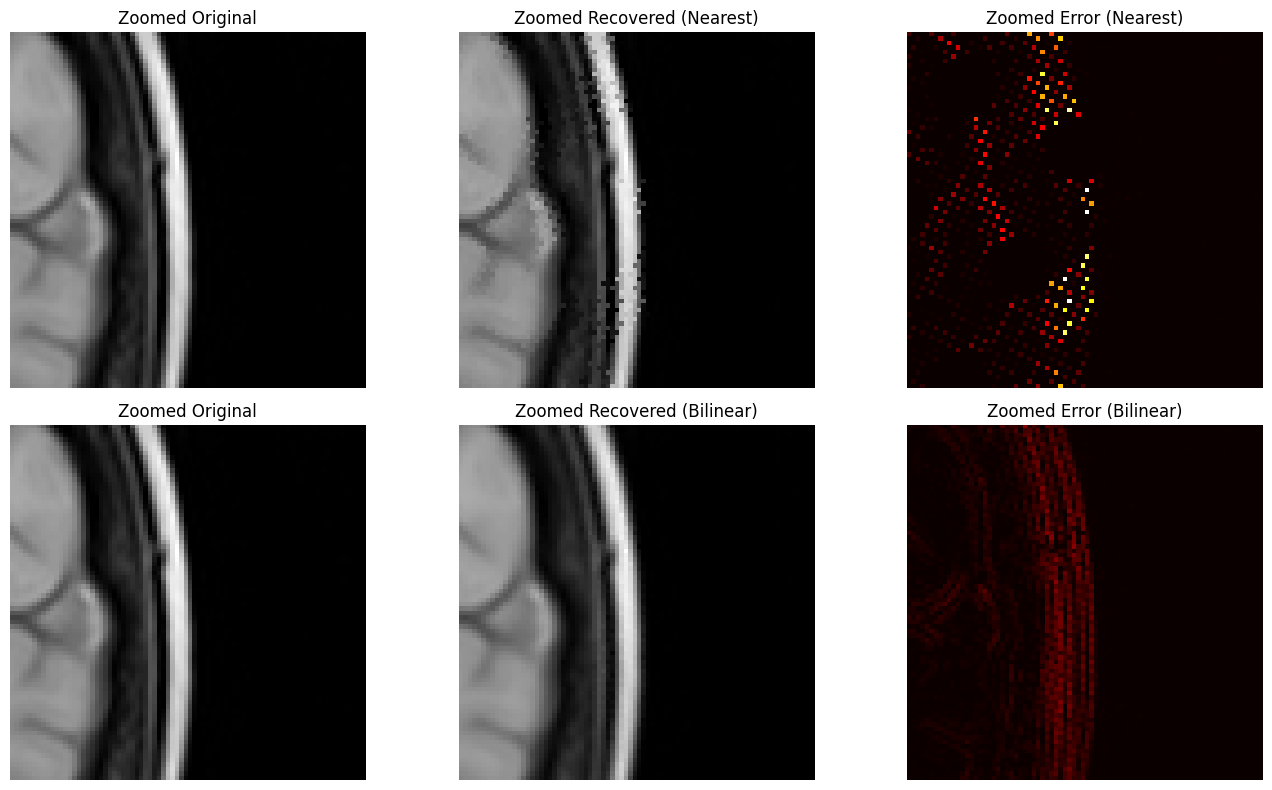

In [31]:
# ------- 主图：在误差图上画箭头和框 -------
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

axes[0].imshow(diff_nn, cmap="hot")
axes[0].set_title("Error Map (Nearest)")
axes[0].axis("off")
axes[0].add_patch(Rectangle((x0, y0), x1 - x0, y1 - y0, fill=False, edgecolor="cyan", linewidth=2))
axes[0].annotate(
    "notable region",
    xy=(cx_peak, cy_peak),
    xytext=(cx_peak + 30, cy_peak - 30),
    color="cyan",
    arrowprops=dict(arrowstyle="->", color="cyan", lw=2)
)

axes[1].imshow(diff_bl, cmap="hot")
axes[1].set_title("Error Map (Bilinear)")
axes[1].axis("off")
axes[1].add_patch(Rectangle((x0, y0), x1 - x0, y1 - y0, fill=False, edgecolor="cyan", linewidth=2))
axes[1].annotate(
    "notable region",
    xy=(cx_peak, cy_peak),
    xytext=(cx_peak + 30, cy_peak - 30),
    color="cyan",
    arrowprops=dict(arrowstyle="->", color="cyan", lw=2)
)

plt.tight_layout()
plt.show()

# ------- 局部放大对比 -------
crop_img = img[y0:y1, x0:x1]
crop_nn  = rec_nn[y0:y1, x0:x1]
crop_bl  = rec_bl[y0:y1, x0:x1]
crop_dnn = diff_nn[y0:y1, x0:x1]
crop_dbl = diff_bl[y0:y1, x0:x1]

vmax = max(crop_dnn.max(), crop_dbl.max(), 1e-8)

fig, axes = plt.subplots(2, 3, figsize=(14, 8))

axes[0, 0].imshow(crop_img, cmap="gray")
axes[0, 0].set_title("Zoomed Original")
axes[0, 0].axis("off")

axes[0, 1].imshow(crop_nn, cmap="gray")
axes[0, 1].set_title("Zoomed Recovered (Nearest)")
axes[0, 1].axis("off")

axes[0, 2].imshow(crop_dnn, cmap="hot", vmin=0, vmax=vmax)
axes[0, 2].set_title("Zoomed Error (Nearest)")
axes[0, 2].axis("off")

axes[1, 0].imshow(crop_img, cmap="gray")
axes[1, 0].set_title("Zoomed Original")
axes[1, 0].axis("off")

axes[1, 1].imshow(crop_bl, cmap="gray")
axes[1, 1].set_title("Zoomed Recovered (Bilinear)")
axes[1, 1].axis("off")

axes[1, 2].imshow(crop_dbl, cmap="hot", vmin=0, vmax=vmax)
axes[1, 2].set_title("Zoomed Error (Bilinear)")
axes[1, 2].axis("off")

plt.tight_layout()
plt.show()

log std:
a=0.3 : 0.324736
a=0.7 : 0.332076
a=1.0 : 0.336299
a=2.0 : 0.346081
a=4.0 : 0.356841

gamma std:
g=0.4 : 0.370498
g=0.7 : 0.340420
g=1.0 : 0.317127
g=1.4 : 0.293623
g=2.0 : 0.268429


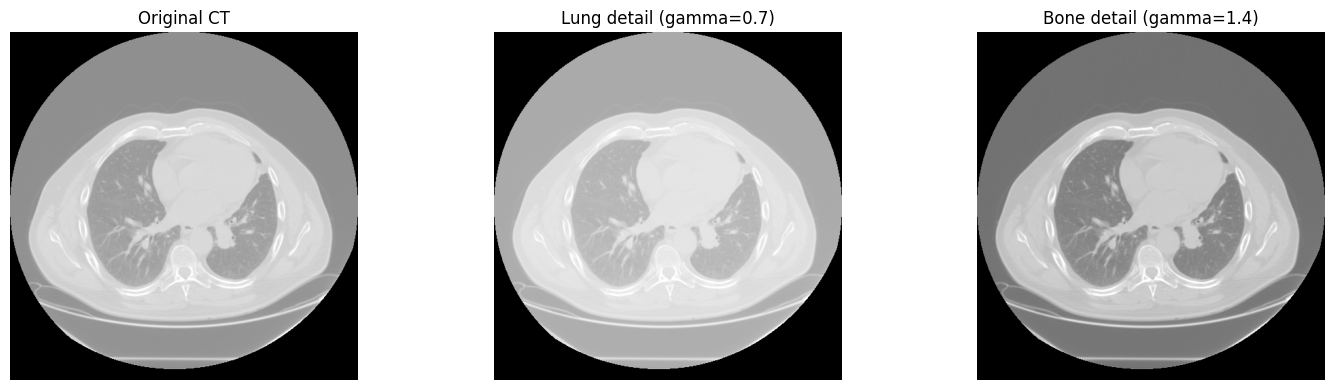

In [33]:
import numpy as np
import matplotlib.pyplot as plt

ct = np.load("lab2_CT.npy").astype(np.float64)
if ct.ndim == 3:
    ct = ct.mean(axis=-1)

ct_n = (ct - ct.min()) / (ct.max() - ct.min() + 1e-8)

def log_transform(img01, a=1.0, c=1.0):
    return np.clip(c * np.log1p(a * img01) / np.log1p(a), 0, 1)

def power_transform(img01, gamma=1.0, c=1.0):
    return np.clip(c * np.power(img01, gamma), 0, 1)

a_list = [0.3, 0.7, 1.0, 2.0, 4.0]
g_list = [0.4, 0.7, 1.0, 1.4, 2.0]

def contrast_score(img01):
    return float(img01.std())

print("log std:")
for a in a_list:
    out = log_transform(ct_n, a=a)
    print(f"a={a:<4}: {contrast_score(out):.6f}")

print("\ngamma std:")
for g in g_list:
    out = power_transform(ct_n, gamma=g)
    print(f"g={g:<4}: {contrast_score(out):.6f}")

best_lung = power_transform(ct_n, gamma=0.7)
best_bone = power_transform(ct_n, gamma=1.4)

fig, ax = plt.subplots(1, 3, figsize=(15, 4))
ax[0].imshow(ct_n, cmap='gray'); ax[0].set_title('Original CT'); ax[0].axis('off')
ax[1].imshow(best_lung, cmap='gray'); ax[1].set_title('Lung detail (gamma=0.7)'); ax[1].axis('off')
ax[2].imshow(best_bone, cmap='gray'); ax[2].set_title('Bone detail (gamma=1.4)'); ax[2].axis('off')
plt.tight_layout(); plt.show()

=== Log transform: global std ===
a=0.1   std=0.319939
a=0.2   std=0.322459
a=0.3   std=0.324736
a=0.5   std=0.328708
a=0.7   std=0.332076
a=1.0   std=0.336299
a=1.5   std=0.341818
a=2.0   std=0.346081
a=3.0   std=0.352355
a=4.0   std=0.356841
a=6.0   std=0.362995

=== Gamma transform: global std ===
g=0.2   std=0.395354
g=0.3   std=0.382389
g=0.4   std=0.370498
g=0.5   std=0.359594
g=0.7   std=0.340420
g=0.9   std=0.324253
g=1.0   std=0.317127
g=1.2   std=0.304480
g=1.4   std=0.293623
g=1.7   std=0.279907
g=2.0   std=0.268429
g=2.5   std=0.252449


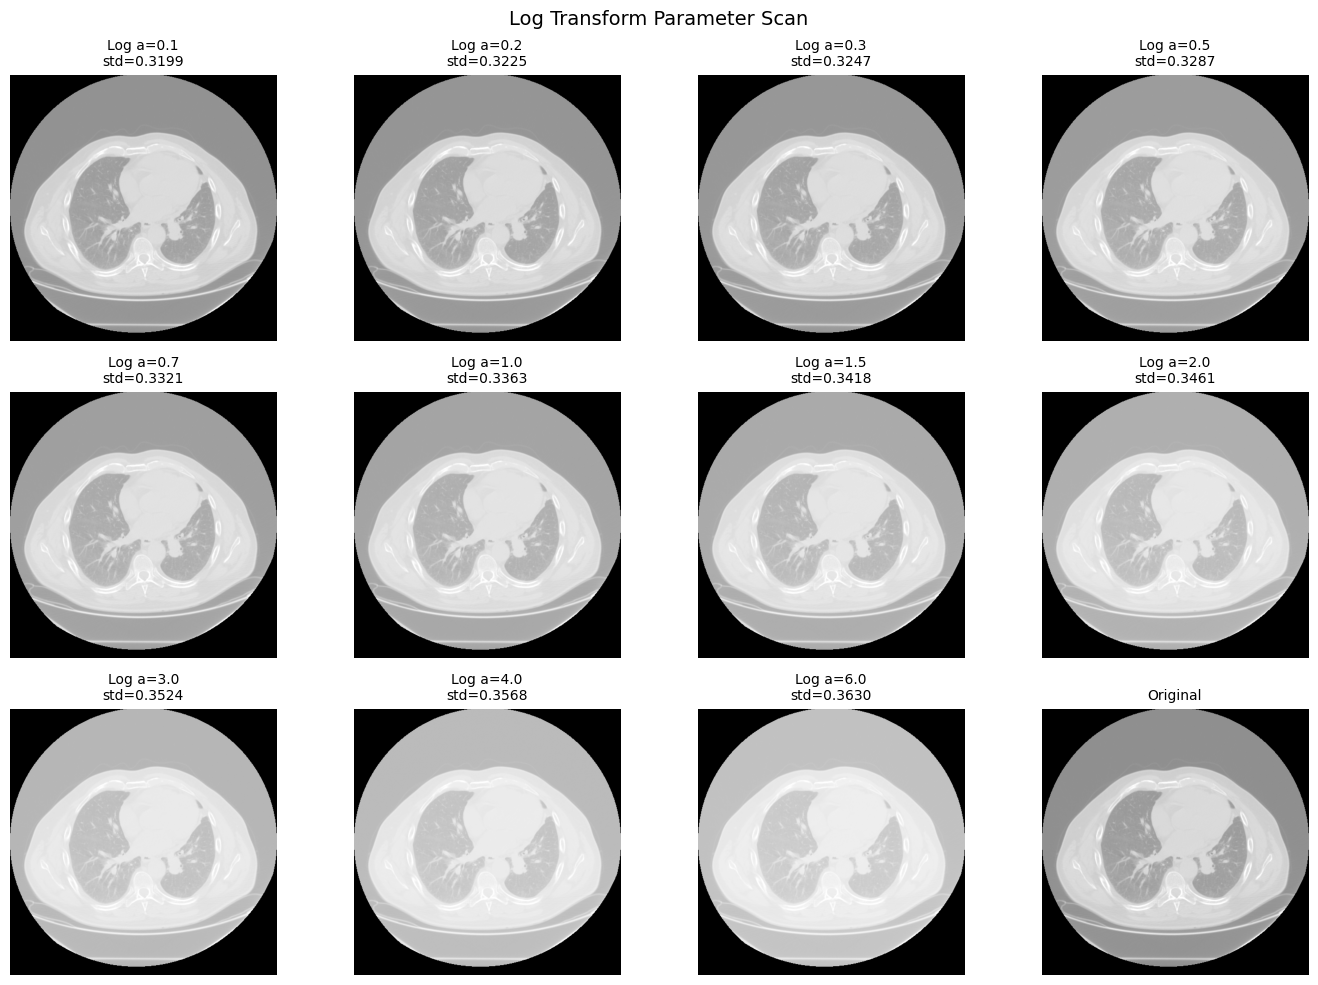

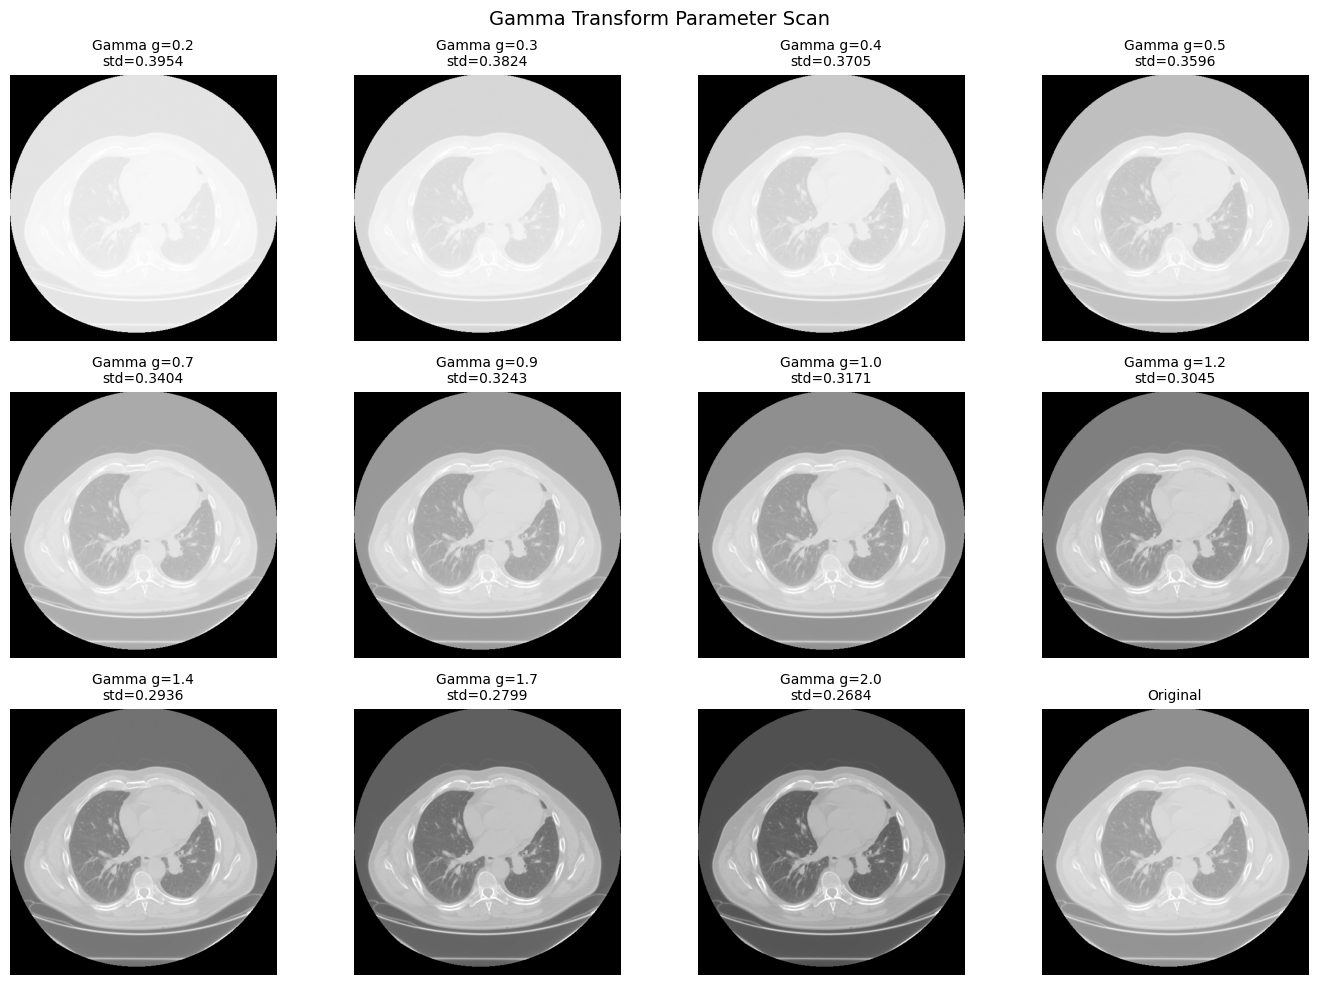

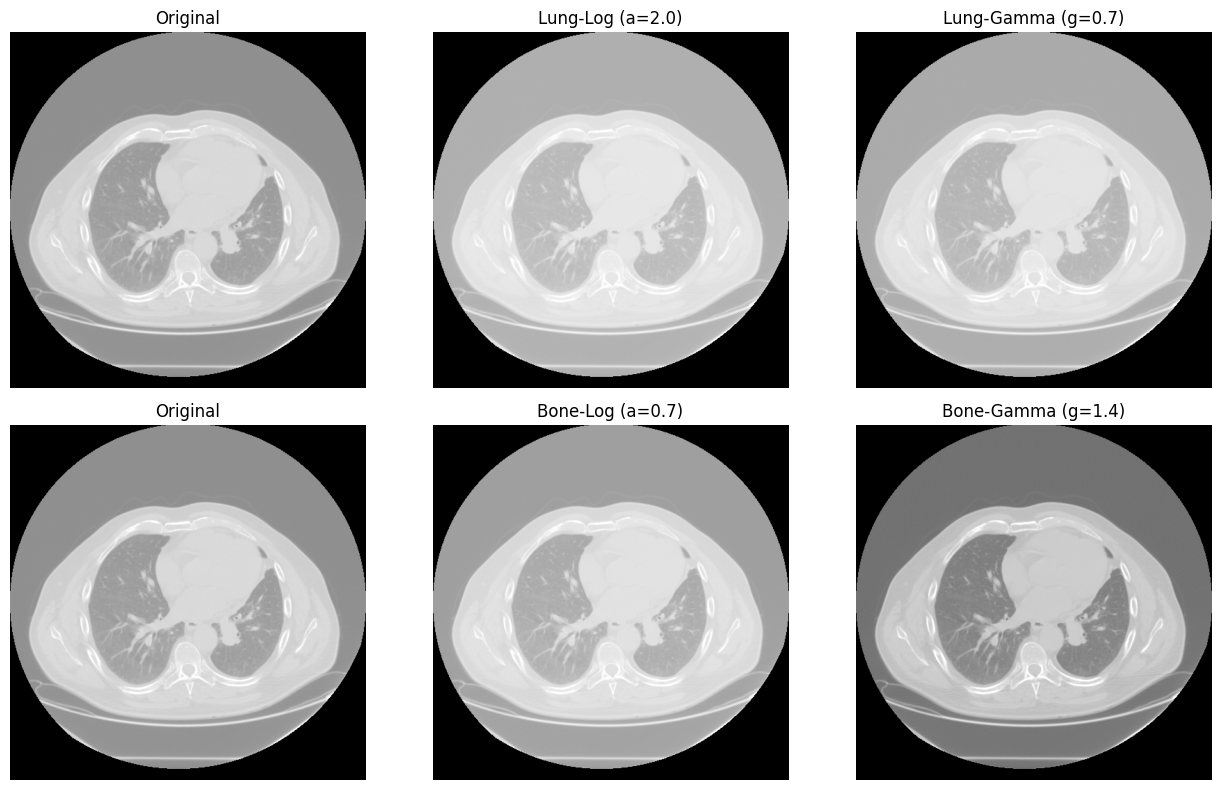

In [36]:
# ===== 多参数可视化：Log 与 Gamma 参数扫描 =====

# 1) 扩展参数列表（比前面更细）
a_scan = [0.1, 0.2, 0.3, 0.5, 0.7, 1.0, 1.5, 2.0, 3.0, 4.0, 6.0]
g_scan = [0.2, 0.3, 0.4, 0.5, 0.7, 0.9, 1.0, 1.2, 1.4, 1.7, 2.0, 2.5]

# 2) 打印每个参数的全局 std（先看趋势）
print("=== Log transform: global std ===")
for a in a_scan:
    out = log_transform(ct_n, a=a)
    print(f"a={a:<4}  std={out.std():.6f}")

print("\n=== Gamma transform: global std ===")
for g in g_scan:
    out = power_transform(ct_n, gamma=g)
    print(f"g={g:<4}  std={out.std():.6f}")

# 3) 画 Log 参数对比图（3x4）
fig, axes = plt.subplots(3, 4, figsize=(14, 10))
for i, a in enumerate(a_scan):
    r, c = divmod(i, 4)
    out = log_transform(ct_n, a=a)
    axes[r, c].imshow(out, cmap="gray")
    axes[r, c].set_title(f"Log a={a}\nstd={out.std():.4f}", fontsize=10)
    axes[r, c].axis("off")

# 最后一个空位补原图，方便对照
axes[2, 3].imshow(ct_n, cmap="gray")
axes[2, 3].set_title("Original", fontsize=10)
axes[2, 3].axis("off")

plt.suptitle("Log Transform Parameter Scan", fontsize=14)
plt.tight_layout()
plt.show()

# 4) 画 Gamma 参数对比图（3x4）
fig, axes = plt.subplots(3, 4, figsize=(14, 10))
for i, g in enumerate(g_scan):
    r, c = divmod(i, 4)
    out = power_transform(ct_n, gamma=g)
    axes[r, c].imshow(out, cmap="gray")
    axes[r, c].set_title(f"Gamma g={g}\nstd={out.std():.4f}", fontsize=10)
    axes[r, c].axis("off")

# 最后一个空位补原图，方便对照
axes[2, 3].imshow(ct_n, cmap="gray")
axes[2, 3].set_title("Original", fontsize=10)
axes[2, 3].axis("off")

plt.suptitle("Gamma Transform Parameter Scan", fontsize=14)
plt.tight_layout()
plt.show()

# 5) 给出两组“任务导向”示例参数并并排展示（肺 vs 骨）
# 你可按观察再微调
lung_log_a, lung_gamma = 2.0, 0.7
bone_log_a, bone_gamma = 0.7, 1.4

lung_log_img   = log_transform(ct_n, a=lung_log_a)
lung_gamma_img = power_transform(ct_n, gamma=lung_gamma)
bone_log_img   = log_transform(ct_n, a=bone_log_a)
bone_gamma_img = power_transform(ct_n, gamma=bone_gamma)

fig, ax = plt.subplots(2, 3, figsize=(13, 8))
ax[0, 0].imshow(ct_n, cmap="gray");         ax[0, 0].set_title("Original"); ax[0, 0].axis("off")
ax[0, 1].imshow(lung_log_img, cmap="gray"); ax[0, 1].set_title(f"Lung-Log (a={lung_log_a})"); ax[0, 1].axis("off")
ax[0, 2].imshow(lung_gamma_img, cmap="gray"); ax[0, 2].set_title(f"Lung-Gamma (g={lung_gamma})"); ax[0, 2].axis("off")

ax[1, 0].imshow(ct_n, cmap="gray");         ax[1, 0].set_title("Original"); ax[1, 0].axis("off")
ax[1, 1].imshow(bone_log_img, cmap="gray"); ax[1, 1].set_title(f"Bone-Log (a={bone_log_a})"); ax[1, 1].axis("off")
ax[1, 2].imshow(bone_gamma_img, cmap="gray"); ax[1, 2].set_title(f"Bone-Gamma (g={bone_gamma})"); ax[1, 2].axis("off")

plt.tight_layout()
plt.show()

In [34]:
import numpy as np
import matplotlib.pyplot as plt

ct = np.load("lab2_CT.npy").astype(np.float64)
if ct.ndim == 3:
    ct = ct.mean(axis=-1)
ct_n = (ct - ct.min()) / (ct.max() - ct.min() + 1e-8)

def log_transform(img01, a=1.0, c=1.0):
    return np.clip(c * np.log1p(a * img01) / np.log1p(a), 0, 1)

def power_transform(img01, gamma=1.0, c=1.0):
    return np.clip(c * np.power(img01, gamma), 0, 1)

def score_std(img01):
    return float(np.std(img01))

def score_entropy(img01, bins=256):
    h, _ = np.histogram(np.clip(img01, 0, 1), bins=bins, range=(0, 1), density=True)
    h = h[h > 1e-12]
    return float(-(h * np.log2(h)).sum())

a_grid = np.array([0.2, 0.4, 0.7, 1.0, 1.5, 2.0, 3.0, 4.0])
g_grid = np.array([0.4, 0.6, 0.7, 0.9, 1.0, 1.2, 1.4, 1.8, 2.2])

log_records = []
for a in a_grid:
    out = log_transform(ct_n, a=a)
    log_records.append(("log", float(a), score_std(out), score_entropy(out)))

gamma_records = []
for g in g_grid:
    out = power_transform(ct_n, gamma=g)
    gamma_records.append(("gamma", float(g), score_std(out), score_entropy(out)))

def rank_records(records):
    arr = np.array([[r[2], r[3]] for r in records], dtype=np.float64)
    mn = arr.min(axis=0)
    mx = arr.max(axis=0)
    norm = (arr - mn) / (mx - mn + 1e-12)
    score = 0.5 * norm[:, 0] + 0.5 * norm[:, 1]
    order = np.argsort(-score)
    return order, score

order_log, score_log = rank_records(log_records)
order_gamma, score_gamma = rank_records(gamma_records)

print("Top-5 Log parameters (a):")
for i in order_log[:5]:
    kind, p, s1, s2 = log_records[i]
    print(f"a={p:<4.1f} | std={s1:.6f} | entropy={s2:.6f} | mix={score_log[i]:.6f}")

print("\nTop-5 Gamma parameters (gamma):")
for i in order_gamma[:5]:
    kind, p, s1, s2 = gamma_records[i]
    print(f"gamma={p:<4.1f} | std={s1:.6f} | entropy={s2:.6f} | mix={score_gamma[i]:.6f}")

best_a = log_records[order_log[0]][1]
best_g = gamma_records[order_gamma[0]][1]
print(f"\nAuto-selected: best_a={best_a}, best_gamma={best_g}")

Top-5 Log parameters (a):
a=1.5  | std=0.341818 | entropy=-864.235433 | mix=0.599482
a=3.0  | std=0.352355 | entropy=-907.866612 | mix=0.596498
a=0.7  | std=0.332076 | entropy=-831.607254 | mix=0.574635
a=2.0  | std=0.346081 | entropy=-889.604294 | mix=0.570648
a=1.0  | std=0.336299 | entropy=-853.848616 | mix=0.556422

Top-5 Gamma parameters (gamma):
gamma=1.0  | std=0.317127 | entropy=-800.775732 | mix=0.754807
gamma=0.9  | std=0.324253 | entropy=-820.811187 | mix=0.737576
gamma=0.7  | std=0.340420 | entropy=-861.469716 | mix=0.710434
gamma=1.2  | std=0.304480 | entropy=-800.775732 | mix=0.696709
gamma=0.6  | std=0.349594 | entropy=-887.264524 | mix=0.688246

Auto-selected: best_a=1.5, best_gamma=1.0


In [37]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.ndimage import convolve as nd_convolve

def conv2_same(img, kernel):
    return nd_convolve(img, kernel, mode="constant", cval=0.0)

xraw = np.load("lab2_filter.npy")
img = xraw.astype(np.float64)
K_lap8 = np.array([[-1, -1, -1], [-1, 8, -1], [-1, -1, -1]], dtype=np.float64)

# ? img.ndim == 3???????weights.ndim (2) must match len(axes) (3)
lap = conv2_same(img, K_lap8)
print(lap.shape)

RuntimeError: weights.ndim (2) must match len(axes) (3)

In [41]:
import numpy as np
x = np.load("lab2_filter.npy")
print(x.shape, x.ndim)

(747, 470, 4) 3


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.ndimage import convolve as nd_convolve

def conv2_same(img2d, kernel2d):
    return nd_convolve(img2d, kernel2d, mode="constant", cval=0.0)

def to_gray(img):
    if img.ndim == 2:
        return img.astype(np.float64)
    if img.ndim == 3:
        x = img.astype(np.float64)
        if img.shape[-1] >= 3:
            return 0.299 * x[..., 0] + 0.587 * x[..., 1] + 0.114 * x[..., 2]
        return x.mean(axis=-1)
    raise ValueError(f"Unsupported ndim={img.ndim}")

def norm01(x):
    mn, mx = np.min(x), np.max(x)
    return np.zeros_like(x) if mx - mn < 1e-12 else (x - mn) / (mx - mn)

def score_sharpness(im):
    gx = np.diff(im, axis=1, prepend=im[:, :1])
    gy = np.diff(im, axis=0, prepend=im[:1, :])
    return float(np.mean(np.sqrt(gx * gx + gy * gy)))

def score_noise_proxy(im):
    lap_k = np.array([[0, -1, 0], [-1, 4, -1], [0, -1, 0]], dtype=np.float64)
    lap = conv2_same(im, lap_k)
    return float(np.std(lap))

raw = np.load("lab2_filter.npy")
img = norm01(to_gray(raw))

K_lap8 = np.array([[-1, -1, -1], [-1, 8, -1], [-1, -1, -1]], dtype=np.float64)
K_sobel_x = np.array([[-1, 0, 1], [-2, 0, 2], [-1, 0, 1]], dtype=np.float64)
K_sobel_y = np.array([[-1, -2, -1], [0, 0, 0], [1, 2, 1]], dtype=np.float64)

lap = conv2_same(img, K_lap8)
Gx = conv2_same(img, K_sobel_x)
Gy = conv2_same(img, K_sobel_y)
Gmag = np.sqrt(Gx**2 + Gy**2)
Gmag_n = norm01(Gmag)

k_grid = np.array([0.05, 0.10, 0.15, 0.20, 0.25, 0.30])
a_grid = np.array([0.10, 0.20, 0.30, 0.35, 0.40, 0.50])

records = []
for k in k_grid:
    sharp = np.clip(img + k * lap, 0, 1)
    for a in a_grid:
        fused = np.clip((1 - a) * sharp + a * Gmag_n, 0, 1)
        s_sharp = score_sharpness(fused)
        s_noise = score_noise_proxy(fused)
        # ??????????????????
        mix = s_sharp - 0.35 * s_noise
        records.append((float(k), float(a), s_sharp, s_noise, mix, fused))

records_sorted = sorted(records, key=lambda x: x[4], reverse=True)
print("Top-8 (k_sharp, alpha):")
for r in records_sorted[:8]:
    print(f"k={r[0]:.2f}, a={r[1]:.2f} | sharp={r[2]:.6f}, noise={r[3]:.6f}, mix={r[4]:.6f}")

best_k, best_a3, _, _, _, best_fused = records_sorted[0]
print(f"\nAuto-selected: k_sharp={best_k}, alpha={best_a3}")

Top-8 (k_sharp, alpha):
k=0.05, a=0.10 | sharp=0.009583, noise=0.028519, mix=-0.000399
k=0.10, a=0.10 | sharp=0.010547, noise=0.033457, mix=-0.001163
k=0.15, a=0.10 | sharp=0.011576, noise=0.038485, mix=-0.001894
k=0.05, a=0.20 | sharp=0.009949, noise=0.035188, mix=-0.002367
k=0.20, a=0.10 | sharp=0.012656, noise=0.043572, mix=-0.002594
k=0.10, a=0.20 | sharp=0.010740, noise=0.039342, mix=-0.003030
k=0.25, a=0.10 | sharp=0.013782, noise=0.048698, mix=-0.003262
k=0.15, a=0.20 | sharp=0.011582, noise=0.043606, mix=-0.003680

Auto-selected: k_sharp=0.05, alpha=0.1


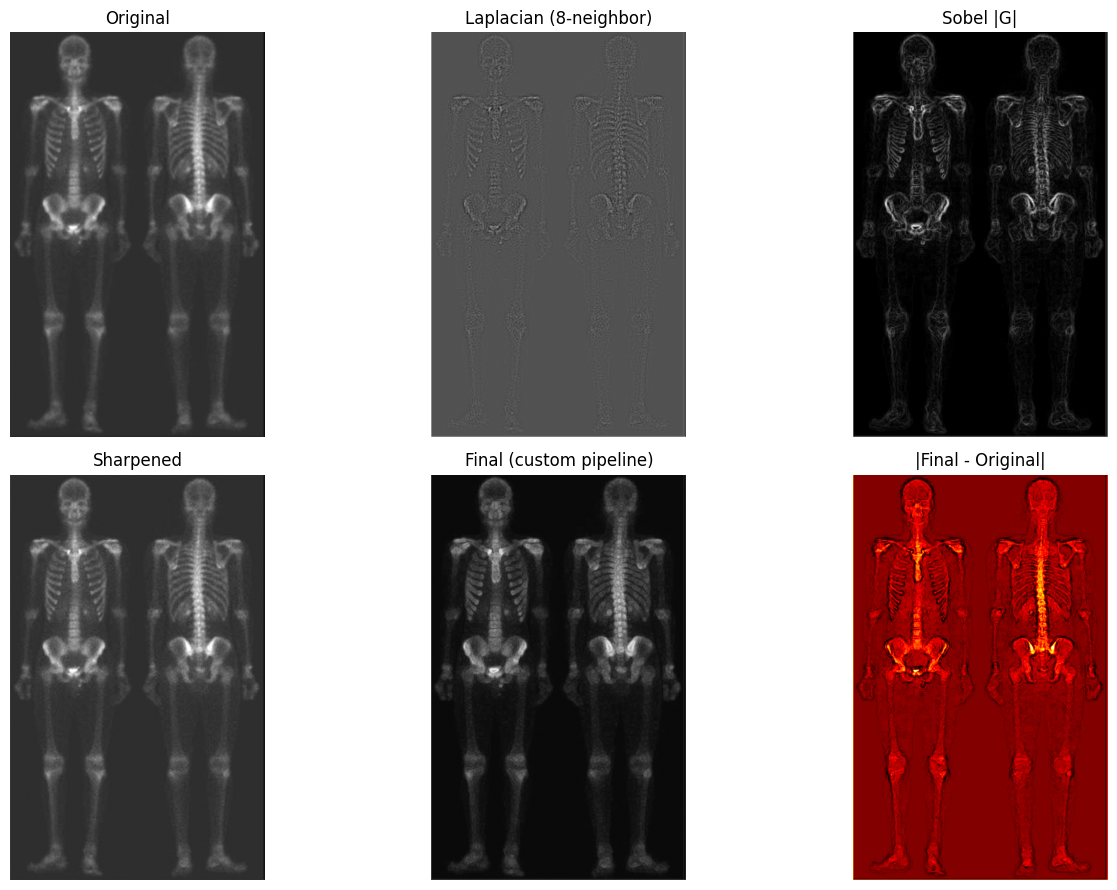

Laplacian std: 0.05450490685686825  | Gmag std: 0.11277192093964605


In [39]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.ndimage import convolve as nd_convolve

def conv2_same(img2d, kernel2d):
    return nd_convolve(img2d, kernel2d, mode="constant", cval=0.0)

def to_gray(img):
    if img.ndim == 2:
        return img.astype(np.float64)
    if img.ndim == 3:
        c = img.shape[-1]
        x = img.astype(np.float64)
        if c >= 3:
            return 0.299 * x[..., 0] + 0.587 * x[..., 1] + 0.114 * x[..., 2]
        return x.mean(axis=-1)
    raise ValueError(f"Unsupported ndim: {img.ndim}")

def norm01(x):
    x = x.astype(np.float64)
    mn, mx = np.min(x), np.max(x)
    if mx - mn < 1e-12:
        return np.zeros_like(x)
    return (x - mn) / (mx - mn)

xraw = np.load("lab2_filter.npy")
gray = to_gray(xraw)
img = norm01(gray)

K_lap8 = np.array([[-1, -1, -1], [-1, 8, -1], [-1, -1, -1]], dtype=np.float64)
K_sobel_x = np.array([[-1, 0, 1], [-2, 0, 2], [-1, 0, 1]], dtype=np.float64)
K_sobel_y = np.array([[-1, -2, -1], [0, 0, 0], [1, 2, 1]], dtype=np.float64)

lap = conv2_same(img, K_lap8)
Gx = conv2_same(img, K_sobel_x)
Gy = conv2_same(img, K_sobel_y)
Gmag = np.sqrt(Gx ** 2 + Gy ** 2)

k_sharp = 0.15
sharp = np.clip(img + k_sharp * lap, 0, 1)

alpha = 0.35
fused = np.clip((1 - alpha) * sharp + alpha * norm01(Gmag), 0, 1)

fig, ax = plt.subplots(2, 3, figsize=(14, 9))
ax[0,0].imshow(img, cmap='gray'); ax[0,0].set_title('Original'); ax[0,0].axis('off')
ax[0,1].imshow(norm01(lap), cmap='gray'); ax[0,1].set_title('Laplacian (8-neighbor)'); ax[0,1].axis('off')
ax[0,2].imshow(norm01(Gmag), cmap='gray'); ax[0,2].set_title('Sobel |G|'); ax[0,2].axis('off')
ax[1,0].imshow(sharp, cmap='gray'); ax[1,0].set_title('Sharpened'); ax[1,0].axis('off')
ax[1,1].imshow(fused, cmap='gray'); ax[1,1].set_title('Final (custom pipeline)'); ax[1,1].axis('off')
ax[1,2].imshow(np.abs(fused - img), cmap='hot'); ax[1,2].set_title('|Final - Original|'); ax[1,2].axis('off')
plt.tight_layout(); plt.show()

print("Laplacian std:", float(lap.std()), " | Gmag std:", float(Gmag.std()))

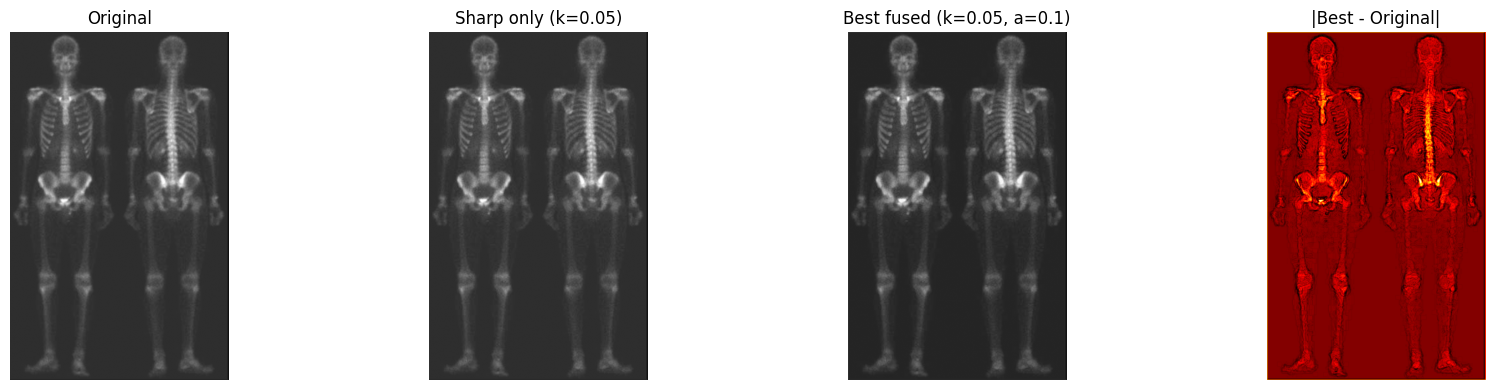

Tuning conclusion:
- Project 2 best log a = 1.5
- Project 2 best gamma = 1.0
- Project 3 best k_sharp = 0.05
- Project 3 best alpha = 0.1


In [40]:
best_sharp = np.clip(img + best_k * lap, 0, 1)

fig, ax = plt.subplots(1, 4, figsize=(18, 4))
ax[0].imshow(img, cmap='gray'); ax[0].set_title('Original'); ax[0].axis('off')
ax[1].imshow(best_sharp, cmap='gray'); ax[1].set_title(f'Sharp only (k={best_k})'); ax[1].axis('off')
ax[2].imshow(best_fused, cmap='gray'); ax[2].set_title(f'Best fused (k={best_k}, a={best_a3})'); ax[2].axis('off')
ax[3].imshow(np.abs(best_fused - img), cmap='hot'); ax[3].set_title('|Best - Original|'); ax[3].axis('off')
plt.tight_layout(); plt.show()

print("Tuning conclusion:")
print(f"- Project 2 best log a = {best_a}")
print(f"- Project 2 best gamma = {best_g}")
print(f"- Project 3 best k_sharp = {best_k}")
print(f"- Project 3 best alpha = {best_a3}")